# Prepare The Data

In [ ]:
import matplotlib.pyplot as plt 
import numpy as np
import cv2
import os
import PIL
import tensorflow as tf
import keras 
from keras import layers, models

In [ ]:
# dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
# data_dir=keras.utils.get_file("flowers_photos",origin=dataset_url,cache_dir=".",untar=True)


In [ ]:
import pathlib

In [ ]:
data_dir="./datasets/flowers_photos/flower_photos"
data_dir=pathlib.Path(data_dir)
data_dir

WindowsPath('datasets/flowers_photos/flower_photos')

In [ ]:
all_images=list(data_dir.glob("*/*.jpg"))

In [ ]:
daisy=list(data_dir.glob("daisy/*"))
len(daisy)

633

In [ ]:
dendelion=list(data_dir.glob("dandelion/*"))
roses=list(data_dir.glob("roses/*"))
sunflowers=list(data_dir.glob("sunflowers/*"))
tulips=list(data_dir.glob("tulips/*"))


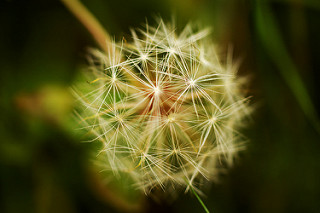

In [ ]:
PIL.Image.open(str(dendelion[0]))

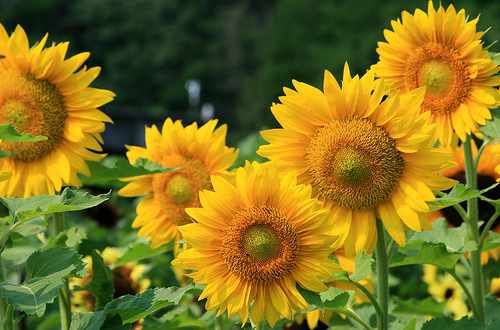

In [ ]:
PIL.Image.open(str(sunflowers[0]))

In [ ]:
flowers_images_dict={
    "roses":roses,
    "daisy":daisy,
    "dendelion":dendelion,
    "sunflowers":sunflowers,
    "tulips":tulips
}

flowers_labels={
    "roses":0,
    "daisy":1,
    "dendelion":2,
    "sunflowers":3,
    "tulips":4
}

In [ ]:
x,y=[],[]

for flower_name,images in flowers_images_dict.items():
    
    for image in images:
        img=cv2.imread(str(image))
        img=cv2.resize(img,(224,224))
        
        x.append(img)
        y.append(flowers_labels[flower_name])
        

In [ ]:
x=np.array(x)
y=np.array(y)

# Train & Test

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=5,test_size=0.2)


# Data Augmentation

In [ ]:
data_augmentation=keras.models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

In [ ]:
classifier=keras.Sequential([
    keras.applications.MobileNetV2(
        weights="imagenet",
        classes=1000
    )
])


In [ ]:
img_array=cv2.imread("fish.jpg")


In [ ]:
img_array=cv2.resize(img_array,(224,224))
img_array.shape

(224, 224, 3)

In [ ]:
img_array=np.expand_dims(img_array,axis=0)
img_array.shape

(1, 224, 224, 3)

In [ ]:
img_array=keras.applications.mobilenet_v2.preprocess_input(img_array)
predictions=classifier.predict(img_array)
np.argmax(predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


np.int64(1)

In [ ]:
decode_prediction=keras.applications.mobilenet_v2.decode_predictions(predictions,top=1)


In [ ]:
print(decode_prediction)
print(type(decode_prediction))

[[('n01443537', 'goldfish', np.float32(0.7031121))]]
<class 'list'>


In [ ]:
base_model=keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

In [ ]:
base_model.trainable=False

In [ ]:
model_flowers=models.Sequential([
    
    base_model,
    layers.Flatten(),
    
    layers.Dense(128,activation="relu"),
    
    layers.Dense(5,activation="softmax")
])

In [ ]:
model_flowers.compile(
    optimizer="adam",
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["acc"]
)


In [ ]:
x_train=keras.applications.mobilenet_v2.preprocess_input(x_train)
x_test=keras.applications.mobilenet_v2.preprocess_input(x_test)

In [ ]:
history=model_flowers.fit(
    x_train,
    y_train,
    epochs=3,
    validation_split=0.2
)

Epoch 1/3
74/74 ━━━━━━━━━━━━━━━━━━━━ 118s 2s/step - acc: 0.7334 - loss: 1.5399 - val_acc: 0.8095 - val_loss: 0.5253
Epoch 2/3
74/74 ━━━━━━━━━━━━━━━━━━━━ 117s 2s/step - acc: 0.9319 - loss: 0.1921 - val_acc: 0.8061 - val_loss: 0.7809
Epoch 3/3
74/74 ━━━━━━━━━━━━━━━━━━━━ 117s 2s/step - acc: 0.9770 - loss: 0.0656 - val_acc: 0.8452 - val_loss: 0.5841


In [ ]:
model_flowers.evaluate(x_test,y_test)

23/23 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - acc: 0.8460 - loss: 0.5099


[0.5099211931228638, 0.8460490703582764]

ResourceExhaustedError: Exception encountered when calling RandomFlip.call().

[1m{{function_node __wrapped__ReverseV2_device_/job:localhost/replica:0/task:0/device:CPU:0}} OOM when allocating tensor with shape[3670,224,224,3] and type float on /job:localhost/replica:0/task:0/device:CPU:0 by allocator mklcpu [Op:ReverseV2][0m

Arguments received by RandomFlip.call():
  • data=tf.Tensor(shape=(3670, 224, 224, 3), dtype=float32)
  • training=True

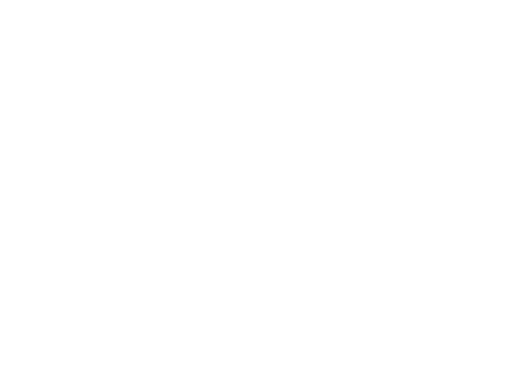

In [ ]:
# plt.axis("off")
# plt.imshow(data_augmentation(x)[0].numpy())

In [ ]:
model_flowers.save("flowers_transfer_model.keras")


ValueError: I/O operation on closed file.

In [ ]:
base_model.save("mobilenetv2_base_model.keras")